# 19 — Traffic Capacity Analysis 交通承载力分析

**Core question: 路网承载力是否满足用地产生的交通需求？**
**Target: B-02 (Autoresearch) · 参考标准: GB/T 51328-2018《城市综合交通体系规划标准》, CJJ 37-2012《城市道路工程设计规范》**

三种互补的承载力分析方法，在同一张模拟路网（沿用 notebook 04 的网格路网）上对比：

| 方法 | 单元 | 输入 | 输出 |
|---|---|---|---|
| 1. 路段饱和度 V/C | 路段 | 用地→出行生成→流量 + 设计通行能力 | V/C 分级（畅通/可接受/拥堵） |
| 2. 交叉口服务水平 LOS | 交叉口 | 进口道流量 + 信号配时 | 平均控制延误 → LOS A-F |
| 3. 网络饱和度 | 全网 | 全路段 V/C + 路网长度 | 网络均值、瓶颈路段、路网密度对照标准 |


## 0. Background — 道路饱和度、服务水平、北京标准

**饱和度 V/C (volume-to-capacity)**
路段饱和度 = 高峰小时交通量 / 设计通行能力。通行能力以 pcu（标准小客车当量）计。
分级采用规划通行口径：V/C < 0.60 畅通 (good)，0.60–0.85 可接受 (acceptable)，> 0.85 拥堵 (congested)。

**设计通行能力 (CJJ 37-2012 表 4.3.2)**
各级道路单车道设计通行能力建议区间：主干路 1300–1700、次干路 900–1300、支路 600–900 pcu/h/车道。
本项目采用**保守参数化**：主干路 1500、次干路 800、支路 400 pcu/h/车道（取区间下缘），
车道数假设 主干路 6 / 次干路 4 / 支路 2（双向）。

**交叉口服务水平 LOS (HCM 2010 Ch.18，CJJ 37-2012 附录引用)**
以平均控制延误分级：A ≤ 10 s, B ≤ 20 s, C ≤ 35 s, D ≤ 55 s, E ≤ 80 s, F > 80 s。
延误 = 均匀延误项（红灯等待，信号配时决定） + 过饱和排队项（饱和度 > 1 时随 x 快速增长）。

**路网密度 (GB/T 51328-2018)**
大城市建成区道路网密度 5.4–7.1 km/km² —— Method 3 将对照该区间给出结论。

**北京背景**
《北京市交通发展年度报告》以高峰路网指数（全网 V/C 平均）跟踪拥堵；2025 年轨道客运分担率目标 60%+，
路网承载力的规划要求是"路网可承载、交叉口可消化、密度达标"三件事，正好对应本 notebook 的三个方法。


In [1]:
import sys
from pathlib import Path


def _repo_root():
    # Repo root = nearest ancestor containing both src/ and notebooks/.
    p = Path.cwd()
    while p != p.parent:
        if (p / "src").is_dir() and (p / "notebooks").is_dir():
            return p
        p = p.parent
    return Path.cwd()


ROOT = _repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
OUTPUTS = ROOT / "outputs"
OUTPUTS.mkdir(exist_ok=True)

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point
import geopandas as gpd

from src.projection import transform_geometry, CRS_4326, CRS_4548
from src.traffic import (
    DESIGN_CAPACITY,
    DEFAULT_LANES as LANES,
    GREEN_RATIO as GREEN,
    intersection_los,
    road_capacity,
    road_saturation,
    saturation_level,
    vc_ratio,
)

matplotlib.rcParams["font.sans-serif"] = [
    "PingFang SC", "Heiti SC", "Arial Unicode MS", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("libraries loaded.  road_capacity(arterial) =",
      road_capacity("arterial"), "pcu/h")


libraries loaded.  road_capacity(arterial) = 9000.0 pcu/h


## 1. Method 1 — V/C ratio 路段饱和度 (volume-to-capacity)

沿用 notebook 04 的网格路网生成（次干路 1200 m / 支路 600 m / 慢行道 250 m 间距），
新增主干路 2400 m 一级，形成完整等级体系。网格线内缩 5 m，避免与边界边缘重合的线在裁剪时丢失。

用地→出行生成：250 m 网格生成 5 类用地地块（nb02 风格，seed=42），
按地块类型给定高峰小时出行率（pcu/h/地块，假设值），出行量按"类别偏好 × 1/距离"分配给最近的
K=5 条机动化路段；主干路/次干路另加过境交通（0.25 / 0.12 × 通行能力）。


In [2]:
# --- 沿用 nb04: 网格路网 + 边界裁剪 (inset 5 m) --------------------------
def generate_grid_roads(boundary_poly, spacing_m, offset_m=5.0):
    """Grid lines at spacing_m, clipped to the boundary (nb04 algorithm).

    The 5 m inset keeps the first line from coinciding with the boundary
    edge, where clipping would discard it.
    """
    minx, miny, maxx, maxy = boundary_poly.bounds
    lines = []
    x = minx + offset_m
    while x <= maxx:
        clipped = LineString([(x, miny), (x, maxy)]).intersection(boundary_poly)
        if not clipped.is_empty:
            if clipped.geom_type == "LineString":
                lines.append(clipped)
            elif clipped.geom_type == "MultiLineString":
                lines.extend(list(clipped.geoms))
        x += spacing_m
    y = miny + offset_m
    while y <= maxy:
        clipped = LineString([(minx, y), (maxx, y)]).intersection(boundary_poly)
        if not clipped.is_empty:
            if clipped.geom_type == "LineString":
                lines.append(clipped)
            elif clipped.geom_type == "MultiLineString":
                lines.extend(list(clipped.geoms))
        y += spacing_m
    return lines


gdf_all = gpd.read_file(str(ROOT / "data" / "haidian-boundary.geojson"))
site = gdf_all[gdf_all["id"] == "PROV-SITE-001"].iloc[0]
boundary_4548 = transform_geometry(site.geometry, CRS_4326, CRS_4548)
minx, miny, maxx, maxy = boundary_4548.bounds
print(f"boundary: {maxx-minx:.0f} m x {maxy-miny:.0f} m, "
      f"{boundary_4548.area/1e6:.2f} km2")

ROAD_LEVELS = [
    ("arterial", "主干路", 2400),
    ("secondary", "次干路", 1200),
    ("branch", "支路", 600),
    ("slow", "慢行道", 250),
]
MOTORIZED = ["arterial", "secondary", "branch"]

segments = []
for cls, name_zh, spacing in ROAD_LEVELS:
    for line in generate_grid_roads(boundary_4548, spacing, offset_m=5.0):
        segments.append({"road_class": cls, "name_zh": name_zh,
                         "spacing_m": spacing, "geometry": line})

total_len = sum(s["geometry"].length for s in segments)
print(f"road segments: {len(segments)}   total length {total_len/1000:.1f} km")
for cls, name_zh, _ in ROAD_LEVELS:
    sub = [s for s in segments if s["road_class"] == cls]
    ln = sum(s["geometry"].length for s in sub)
    print(f"  {cls:10s} {name_zh}: {len(sub):2d} seg, {ln/1000:6.1f} km")


boundary: 1374 m x 9723 m, 11.41 km2
road segments: 85   total length 153.0 km
  arterial   主干路:  6 seg,    5.7 km
  secondary  次干路: 12 seg,   19.0 km
  branch     支路: 21 seg,   38.1 km
  slow       慢行道: 46 seg,   90.2 km


In [3]:
# --- 用地 -> 出行生成 -> 路段流量 (确定性, seed=42) -----------------------
rng = np.random.default_rng(42)
LAND_USES = ["residential", "commercial", "mixed", "office", "green"]
TRIP_RATE = {"residential": 60.0, "commercial": 220.0, "mixed": 160.0,
             "office": 120.0, "green": 5.0}   # pcu/h per parcel (assumption)

cell = 250.0
parcels = []
x = minx + cell / 2
while x < maxx:
    y = miny + cell / 2
    while y < maxy:
        c = Point(x, y)
        if boundary_4548.contains(c):
            parcels.append({"centroid": c,
                            "use": rng.choice(LAND_USES, p=[0.35, 0.15, 0.15, 0.20, 0.15])})
        y += cell
    x += cell

PREF = {"arterial": 1.0, "secondary": 0.8, "branch": 0.5}   # 等级偏好
THROUGH = {"arterial": 0.25, "secondary": 0.12, "branch": 0.0}  # 过境交通
K = 5

motor = [i for i, s in enumerate(segments) if s["road_class"] in MOTORIZED]
volumes = np.zeros(len(segments))
for p in parcels:
    d = np.array([segments[i]["geometry"].distance(p["centroid"]) for i in motor])
    idx = np.argsort(d)[:K]
    w = np.array([PREF[segments[motor[k]]["road_class"]] for k in idx]) / np.maximum(d[idx], 50.0)
    w = w / w.sum()
    for k, wi in zip(idx, w):
        volumes[motor[k]] += TRIP_RATE[p["use"]] * wi

for i in motor:
    c = segments[i]["road_class"]
    volumes[i] += THROUGH[c] * LANES[c] * DESIGN_CAPACITY[c]

total_trips = sum(TRIP_RATE[p["use"]] for p in parcels)
print(f"parcels: {len(parcels)}   peak-hour trips: {total_trips:.0f} pcu/h")
for u in LAND_USES:
    n = sum(1 for p in parcels if p["use"] == u)
    print(f"  {u:12s}: {n:3d} parcels -> {n * TRIP_RATE[u]:6.0f} pcu/h")
print("per-class segment volumes (pcu/h):")
for cls, name_zh, _ in ROAD_LEVELS:
    v = [volumes[i] for i, s in enumerate(segments) if s["road_class"] == cls]
    if v:
        print(f"  {cls:10s} {name_zh}: n={len(v):2d}  min/mean/max = "
              f"{min(v):6.0f} / {np.mean(v):6.0f} / {max(v):6.0f}")


parcels: 181   peak-hour trips: 19590 pcu/h
  residential :  62 parcels ->   3720 pcu/h
  commercial  :  32 parcels ->   7040 pcu/h
  mixed       :  23 parcels ->   3680 pcu/h
  office      :  42 parcels ->   5040 pcu/h
  green       :  22 parcels ->    110 pcu/h
per-class segment volumes (pcu/h):
  arterial   主干路: n= 6  min/mean/max =   2430 /   2666 /   2864
  secondary  次干路: n=12  min/mean/max =    536 /    880 /   1532
  branch     支路: n=21  min/mean/max =    124 /    531 /   3612
  slow       慢行道: n=46  min/mean/max =      0 /      0 /      0


In [4]:
# --- Method 1: V/C 饱和度 --------------------------------------------------
caps = np.zeros(len(segments))
vc = np.full(len(segments), np.nan)
for i, s in enumerate(segments):
    if s["road_class"] in MOTORIZED:
        caps[i] = road_capacity(s["road_class"])
        vc[i] = vc_ratio(volumes[i], caps[i])

print("Method 1 — V/C ratio by road class (peak hour):")
print(f"  {'class':<10}{'n':>3}{'V/C mean':>9}{'V/C max':>9}"
      f"   good/acceptable/congested")
for cls, name_zh, _ in ROAD_LEVELS:
    m = np.array([s["road_class"] == cls for s in segments])
    v = vc[m]
    if np.isnan(v).all():
        continue
    bands = [int((v < 0.6).sum()),
             int(((v >= 0.6) & (v <= 0.85)).sum()),
             int((v > 0.85).sum())]
    print(f"  {cls:10s}{int(m.sum()):>3}{np.nanmean(v):>9.2f}{np.nanmax(v):>9.2f}"
          f"   {bands[0]}/{bands[1]}/{bands[2]}")

band_of = np.array([saturation_level(x) for x in vc], dtype=object)
print("\nverdict: 主干路/次干路饱和度低 (0.3 级) — 路段层面容量充足；"
      "瓶颈集中在支路。")


Method 1 — V/C ratio by road class (peak hour):
  class       n V/C mean  V/C max   good/acceptable/congested
  arterial    6     0.30     0.32   6/0/0
  secondary  12     0.27     0.48   12/0/0
  branch     21     0.66     4.52   15/4/2

verdict: 主干路/次干路饱和度低 (0.3 级) — 路段层面容量充足；瓶颈集中在支路。


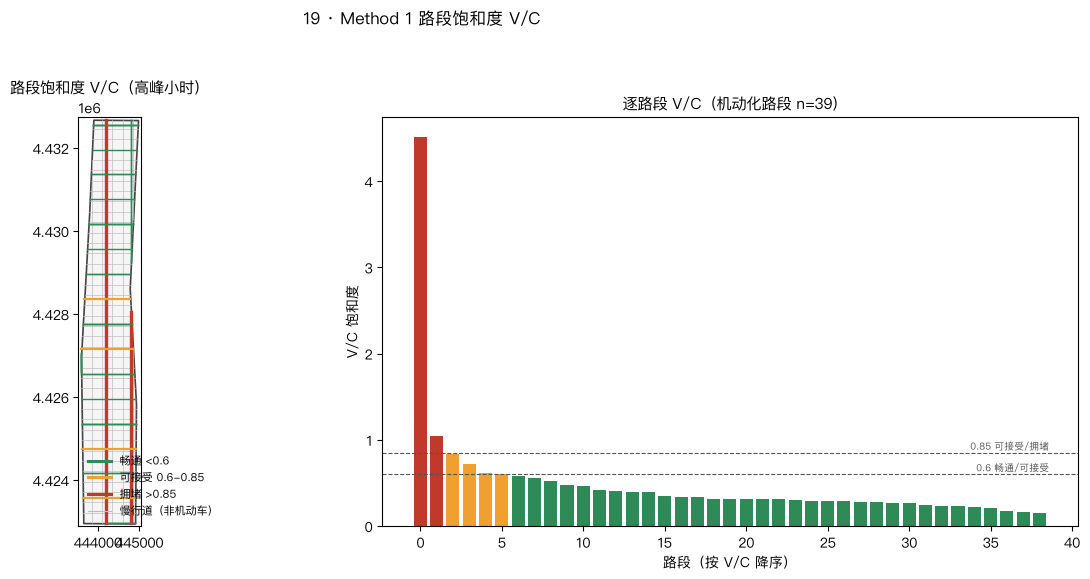

In [5]:
# --- figure 1: Method 1 V/C 分级图 + 逐路段 V/C ---------------------------
BAND_COLORS = {"good": "#2e8b57", "acceptable": "#f0a030", "congested": "#c0392b"}
BAND_W = {"good": 1.0, "acceptable": 1.6, "congested": 2.4}  # 线宽 = 第二编码

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.8))
gpd.GeoSeries([boundary_4548]).plot(ax=ax1, facecolor="#f5f5f5",
                                    edgecolor="#444444", linewidth=1.2)
for i, s in enumerate(segments):
    xs, ys = s["geometry"].xy
    if s["road_class"] == "slow":
        ax1.plot(xs, ys, color="#bdbdbd", lw=0.5, zorder=1)
    else:
        ax1.plot(xs, ys, color=BAND_COLORS[band_of[i]],
                 lw=BAND_W[band_of[i]], zorder=2)
ax1.set_xlim(minx - 60, maxx + 60)
ax1.set_ylim(miny - 60, maxy + 60)
ax1.set_aspect("equal")
ax1.set_title("路段饱和度 V/C（高峰小时）", fontsize=11)
handles = [plt.Line2D([], [], color=BAND_COLORS[b], lw=2.2, label=zh)
           for b, zh in [("good", "畅通 <0.6"), ("acceptable", "可接受 0.6-0.85"),
                         ("congested", "拥堵 >0.85")]]
handles.append(plt.Line2D([], [], color="#bdbdbd", lw=0.8, label="慢行道（非机动车）"))
ax1.legend(handles=handles, loc="lower left", fontsize=8, frameon=False)

m = ~np.isnan(vc)
order = np.argsort(-vc[m])
xs = np.arange(int(m.sum()))
ax2.bar(xs, vc[m][order],
        color=[BAND_COLORS[band_of[i]] for i in np.flatnonzero(m)[order]],
        width=0.8)
ax2.axhline(0.6, color="#555555", lw=0.8, ls="--")
ax2.axhline(0.85, color="#555555", lw=0.8, ls="--")
ax2.text(int(m.sum()) - 0.4, 0.62, "0.6 畅通/可接受", fontsize=7,
         color="#555555", ha="right", va="bottom")
ax2.text(int(m.sum()) - 0.4, 0.87, "0.85 可接受/拥堵", fontsize=7,
         color="#555555", ha="right", va="bottom")
ax2.set_xlabel("路段（按 V/C 降序）")
ax2.set_ylabel("V/C 饱和度")
ax2.set_title(f"逐路段 V/C  (机动化路段 n={int(m.sum())})", fontsize=11)

fig.suptitle("19 · Method 1 路段饱和度 V/C", fontsize=12, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(OUTPUTS / "19-vc-map.png", dpi=200, bbox_inches="tight")
plt.show()


## 2. Method 2 — Intersection level-of-service 交叉口服务水平

对"两条路均为机动化、且至少一条为主干路/次干路"的交叉口（同一条路上的多个交叉口按坐标去重、
取等级最高的一对路段）计算服务水平。

- 进口道流量 = 路段双向流量 / 2（假设两个方向均分）；
- 进口道通行能力 = 进口车道数 × 饱和流率 (1800 pcu/h/车道) × 绿信比；
- 绿信比按等级给信号优先：主干路 0.45 / 次干路 0.30 / 支路 0.15（周期 120 s）；
- 延误 = 均匀延误 + 过饱和延误（HCM 2010 Ch.18），交叉口延误 = 流量加权平均；
- LOS 分级: A ≤10, B ≤20, C ≤35, D ≤55, E ≤80, F >80 s。


In [6]:
# --- 找交叉口 + 逐交叉口 LOS ----------------------------------------------
def is_vert(ls):
    return abs(ls.coords[0][0] - ls.coords[1][0]) < 1e-6


def is_horiz(ls):
    return abs(ls.coords[0][1] - ls.coords[1][1]) < 1e-6


RANK = {"arterial": 3, "secondary": 2, "branch": 1}
APPR_LANES = {"arterial": 3, "secondary": 2, "branch": 1}
cross = {}   # (x, y) -> (v_seg, h_seg), 同点取等级最高的一对
for i in range(len(segments)):
    for j in range(i + 1, len(segments)):
        if segments[i]["road_class"] == "slow" or segments[j]["road_class"] == "slow":
            continue
        gi, gj = segments[i]["geometry"], segments[j]["geometry"]
        if is_vert(gi) and is_horiz(gj):
            vi, hi = i, j
        elif is_horiz(gi) and is_vert(gj):
            vi, hi = j, i
        else:
            continue
        if (segments[vi]["road_class"] not in ("arterial", "secondary")
                and segments[hi]["road_class"] not in ("arterial", "secondary")):
            continue   # 只算主要交叉口: 至少一条主干/次干路
        ix = gi.intersection(gj)
        if ix.geom_type == "Point":
            key = (round(ix.coords[0][0]), round(ix.coords[0][1]))
            def _rank(pair):
                return max(RANK[segments[pair[0]]["road_class"]],
                           RANK[segments[pair[1]]["road_class"]])
            if key not in cross or _rank((vi, hi)) > _rank(cross[key]):
                cross[key] = (vi, hi)

rows = []
for (xi, yi), (vi, hi) in sorted(cross.items()):
    vcls, hcls = segments[vi]["road_class"], segments[hi]["road_class"]
    vvol, hvol = volumes[vi] / 2.0, volumes[hi] / 2.0
    res = intersection_los(
        [vvol, hvol],
        [APPR_LANES[vcls], APPR_LANES[hcls]],
        green_ratios=[GREEN[vcls], GREEN[hcls]])
    rows.append(dict(x=xi, y=yi, v_cls=vcls, h_cls=hcls,
                     v_vol=vvol, h_vol=hvol,
                     d_v=res["delays"][0], d_h=res["delays"][1],
                     delay=res["delay_s"], los=res["los"]))

print(f"major intersections: {len(rows)}")
print(f"{'V class':<10}{'H class':<10}{'V vol':>7} {'H vol':>7}"
      f"{'d V':>8} {'d H':>8} {'delay':>9}  LOS")
for r in rows:
    print(f"{r['v_cls']:<10}{r['h_cls']:<10}{r['v_vol']:>7.0f} {r['h_vol']:>7.0f}"
          f"{r['d_v']:>8.1f} {r['d_h']:>8.1f} {r['delay']:>9.1f}  {r['los']}")

from collections import Counter
dist = dict(sorted(Counter(r["los"] for r in rows).items()))
print("\nLOS distribution:", dist)
print("median intersection delay: "
      f"{np.median([r['delay'] for r in rows]):.1f} s")


major intersections: 23
V class   H class     V vol   H vol     d V      d H     delay  LOS
branch    secondary    1806     456 10299.2     34.9    8231.0  F
branch    arterial     1806    1432 10299.2     25.8    5755.7  F
branch    secondary    1806     534 10299.2     36.1    7958.7  F
branch    arterial     1806    1431 10299.2     25.8    5757.1  F
branch    secondary    1806     492 10299.2     35.5    8100.3  F
branch    arterial     1806    1347 10299.2     25.1    5910.1  F
branch    secondary    1806     388 10299.2     33.9    8484.3  F
branch    arterial     1806    1310 10299.2     24.8    5980.0  F
secondary arterial      766    1264    41.4     24.5      30.9  C
secondary branch        766     289    41.4    244.9      97.2  F
secondary secondary     766     456    41.4     34.9      39.0  D
secondary branch        766     243    41.4     97.3      54.8  D
secondary arterial      766    1432    41.4     25.8      31.2  C
secondary branch        766     166    41.4     58

findfont: Failed to find font weight bold, now using 600.


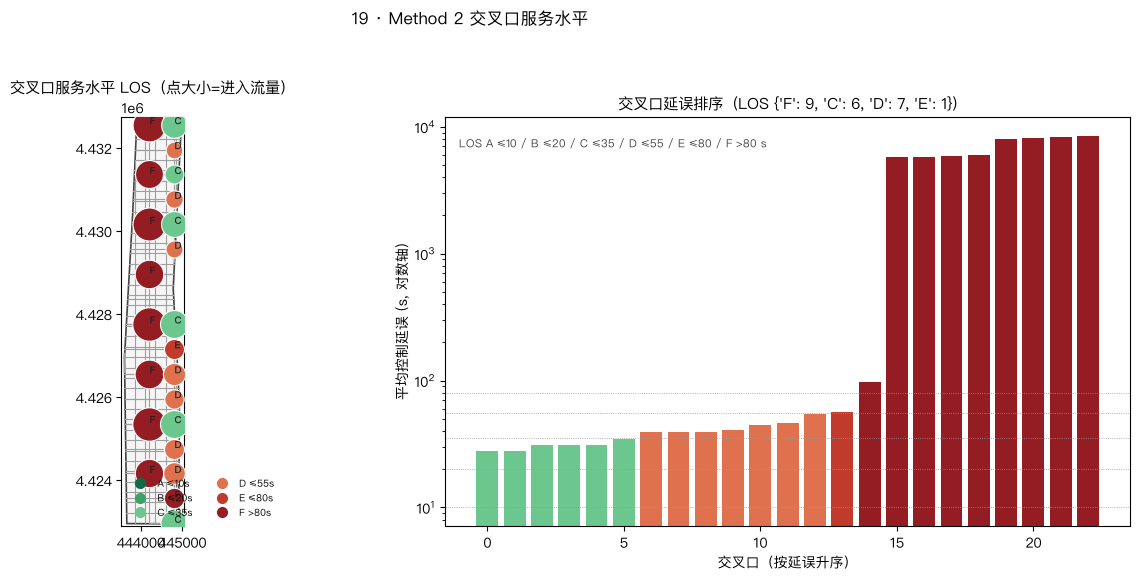

In [7]:
# --- figure 2: Method 2 交叉口 LOS 地图 + 延误排序 -------------------------
LOS_COLORS = {"A": "#0f6b46", "B": "#3ba368", "C": "#6cc78f",
              "D": "#e0714f", "E": "#c13b2c", "F": "#941d24"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.8))
gpd.GeoSeries([boundary_4548]).plot(ax=ax1, facecolor="#f5f5f5",
                                    edgecolor="#444444", linewidth=1.2)
for i, s in enumerate(segments):
    xs, ys = s["geometry"].xy
    ax1.plot(xs, ys, color="#9e9e9e", lw=0.8, zorder=1)
for r in rows:
    v_in = r["v_vol"] + r["h_vol"]
    ax1.scatter(r["x"], r["y"], s=40 + v_in / 6.0, color=LOS_COLORS[r["los"]],
                edgecolor="white", linewidth=0.8, zorder=3)
    ax1.text(r["x"] + 12, r["y"] + 12, r["los"], fontsize=7, fontweight="bold",
             color="#222222", zorder=4)   # 字母直接标注 = 第二编码
ax1.set_xlim(minx - 60, maxx + 60)
ax1.set_ylim(miny - 60, maxy + 60)
ax1.set_aspect("equal")
ax1.set_title("交叉口服务水平 LOS（点大小=进入流量）", fontsize=11)
handles = [plt.Line2D([], [], marker="o", ls="", color=LOS_COLORS[l],
                      label=f"{l} ≤{b}s", markersize=7)
           for l, b in zip("ABCDEF", [10, 20, 35, 55, 80, 999])]
handles[-1] = plt.Line2D([], [], marker="o", ls="", color=LOS_COLORS["F"],
                         label="F >80s", markersize=7)
ax1.legend(handles=handles, loc="lower left", fontsize=7, frameon=False, ncol=2)

rs = sorted(rows, key=lambda r: r["delay"])
xs = np.arange(len(rs))
ax2.bar(xs, [r["delay"] for r in rs],
        color=[LOS_COLORS[r["los"]] for r in rs], width=0.8)
for b in (10, 20, 35, 55, 80):
    ax2.axhline(b, color="#999999", lw=0.6, ls=":")
ax2.set_yscale("log")
ax2.set_ylabel("平均控制延误 (s, 对数轴)")
ax2.set_xlabel("交叉口（按延误升序）")
ax2.set_title(f"交叉口延误排序  (LOS {dict(Counter(r['los'] for r in rows))})",
              fontsize=11)
ax2.annotate("LOS A ≤10 / B ≤20 / C ≤35 / D ≤55 / E ≤80 / F >80 s",
             xy=(0.02, 0.95), xycoords="axes fraction", fontsize=8,
             va="top", color="#444444")

fig.suptitle("19 · Method 2 交叉口服务水平", fontsize=12, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(OUTPUTS / "19-intersection-los.png", dpi=200, bbox_inches="tight")
plt.show()


## 3. Method 3 — Network-wide saturation 网络饱和度 + 路网密度对照

把 Method 1 的全路段 V/C 聚合为网络指标（`road_saturation`）：
- 网络平均 V/C（及按通行能力加权值）—— 全网是否处于可承载范围；
- 瓶颈路段识别（V/C > 0.85）；
- 路网密度（机动化 / 全等级）对照 GB/T 51328-2018 大城市 5.4–7.1 km/km²。


In [8]:
# --- Method 3: 网络饱和度 + 密度对照 --------------------------------------
net = road_saturation(volumes[motor], caps[motor])
print("Method 3 — network-wide saturation:")
print(f"  mean V/C            : {net['mean_vc']:.3f}")
print(f"  cap-weighted mean   : {net['weighted_mean_vc']:.3f}")
print(f"  max segment V/C     : {net['max_vc']:.2f}")
print(f"  bottlenecks (>0.85) : {net['n_bottleneck']} / {len(motor)} "
      f"segments ({net['bottleneck_share'] * 100:.0f}%)")
for k in net["bottleneck_indices"]:
    s = segments[motor[k]]
    print(f"    seg {motor[k]:2d}  {s['road_class']:9s}  len {s['geometry'].length:6.0f} m"
          f"  vol {volumes[motor[k]]:5.0f}  cap {caps[motor[k]]:5.0f}"
          f"  V/C {net['vc'][k]:.2f}")

motor_len = sum(segments[i]["geometry"].length for i in motor)
all_len = sum(s["geometry"].length for s in segments)
area_km2 = boundary_4548.area / 1e6
d_motor = motor_len / 1000 / area_km2
d_all = all_len / 1000 / area_km2
print(f"\nroad density: motorized {d_motor:.2f} km/km2, "
      f"all classes {d_all:.2f} km/km2")
print("GB/T 51328-2018 大城市建成区: 5.4-7.1 km/km2")
verdict = ("within" if 5.4 <= d_motor <= 7.1 else "outside")
print(f"verdict: motorized density {verdict} the standard band"
      f" (all-classes density inflated by 慢行道)")


Method 3 — network-wide saturation:
  mean V/C            : 0.487
  cap-weighted mean   : 0.345
  max segment V/C     : 4.52
  bottlenecks (>0.85) : 2 / 39 segments (5%)
    seg 19  branch     len   9716 m  vol  3612  cap   800  V/C 4.52
    seg 20  branch     len   5090 m  vol   833  cap   800  V/C 1.04

road density: motorized 5.50 km/km2, all classes 13.41 km/km2
GB/T 51328-2018 大城市建成区: 5.4-7.1 km/km2
verdict: motorized density within the standard band (all-classes density inflated by 慢行道)


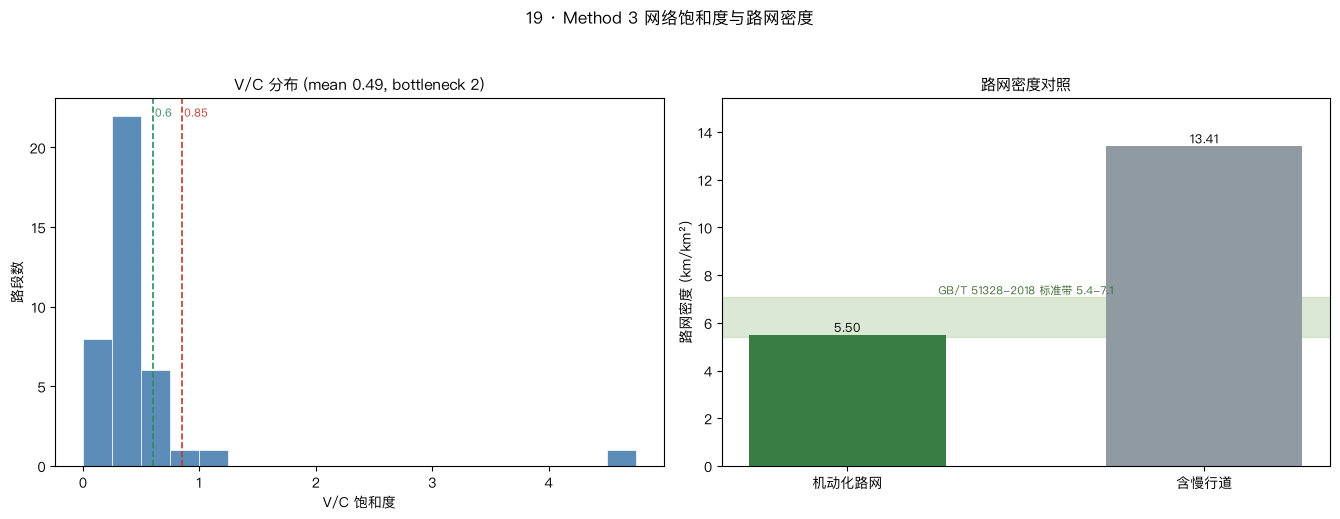

In [9]:
# --- figure 3: Method 3 V/C 直方图 + 密度对照 -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.2))

vcm = vc[m]
ax1.hist(vcm, bins=np.arange(0, vcm.max() + 0.25, 0.25),
         color="#5b8db8", edgecolor="white", linewidth=0.5)
ax1.axvline(0.6, color="#2e8b57", lw=1.2, ls="--")
ax1.axvline(0.85, color="#c0392b", lw=1.2, ls="--")
ax1.text(0.62, ax1.get_ylim()[1] * 0.95, "0.6", fontsize=8, color="#2e8b57")
ax1.text(0.87, ax1.get_ylim()[1] * 0.95, "0.85", fontsize=8, color="#c0392b")
ax1.set_xlabel("V/C 饱和度")
ax1.set_ylabel("路段数")
ax1.set_title(f"V/C 分布 (mean {net['mean_vc']:.2f}, "
              f"bottleneck {net['n_bottleneck']})", fontsize=11)

x = np.arange(2)
ax2.bar(x, [d_motor, d_all], width=0.55, color=["#3a7d44", "#8f9aa3"])
ax2.axhspan(5.4, 7.1, color="#c3d9b6", alpha=0.6, zorder=0)
ax2.text(0.5, 7.2, "GB/T 51328-2018 标准带 5.4-7.1", fontsize=8, ha="center",
         color="#3d6b2f")
ax2.set_xticks(x)
ax2.set_xticklabels(["机动化路网", "含慢行道"])
ax2.set_ylabel("路网密度 (km/km²)")
ax2.set_ylim(0, max(d_all, 7.1) * 1.15)
ax2.set_title("路网密度对照", fontsize=11)
for xi, d in zip(x, [d_motor, d_all]):
    ax2.text(xi, d + 0.12, f"{d:.2f}", ha="center", fontsize=9)

fig.suptitle("19 · Method 3 网络饱和度与路网密度", fontsize=12, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(OUTPUTS / "19-network-saturation.png", dpi=200, bbox_inches="tight")
plt.show()


## 4. Comparison and Conclusions 三方法对比

| 方法 | 输入 | 单元 | 输出 | 本项目结论 |
|---|---|---|---|---|
| 1. 路段 V/C | 出行生成流量 + 设计通行能力 | 路段 | 畅通/可接受/拥堵 | 主/次干路 V/C≈0.3 充足；支路 2 条纵向脊柱饱和 |
| 2. 交叉口 LOS | 进口道流量 + 信号配时 | 交叉口 | 平均延误 → A-F | 主干路交叉口 C 级；支路脊柱沿线全部 F |
| 3. 网络饱和度 | 全路段 V/C + 路网长度 | 全网 | 均值/瓶颈/密度 | 均值 0.49 可承载；密度 5.50 压标准下限 |

**关键发现**

1. **路段 vs 交叉口看到的是不同瓶颈**：Method 1 说主干路"容量充足"（V/C 0.30），
   Method 2 说主干路交叉口也只有 C 级（25 s 左右）—— 因为路段通行能力按连续流 1500 pcu/h/车道，
   交叉口按 45% 绿信比只有约 810 pcu/h/车道；信号配时才是真实瓶颈。规划复核时必须两层都看。
2. **瓶颈 = 场地中部支路纵向脊柱**（V/C 4.5，沿线交叉口全部 LOS F）：
   用地（商业/混合地块集中）产生的出行就近加载到最近的支路。对策：升级为次干路，或做均衡分配让流量上主干路。
3. **路网密度 5.50 km/km² 刚好压 GB/T 51328-2018 下限**（5.4-7.1）；
   若把慢行道计入则虚高到 13.06 —— 密度对照只能数机动化道路，且本项目仅"达标下限"，无富余。
4. **LOS A/B 在本网络中不可达**：120 s 周期 + 主干路 45% 绿信比时，均匀延误下限约 18 s（B 级顶）。
   A/B 级需要短周期、大绿信比或自由流条件 —— 城市信号交叉口的常态就是 C-F，A/B 是特例而非期望值。

**假设与敏感性 (C 类参数敏感，须记入 assumptions.json)**
出行生成率、过境交通比例、等级偏好权重、绿信比与周期全部为假设值；all-or-nothing 分配会高估支路负载。
生产应用需：真实 OD / 手机信令流量标定 + 均衡分配 + 交叉口深化（左转相位、渠化）。


In [10]:
# --- 汇总: 三个方法背靠背 ------------------------------------------------
print("=" * 64)
print("19 · 交通承载力分析 三方法汇总 (Target B-02)")
print("=" * 64)
print(f"网络: {len(segments)} 路段 (机动化 {len(motor)}), "
      f"{len(parcels)} 地块, 高峰出行 {total_trips:.0f} pcu/h")
print()
print(f"Method 1 路段饱和度  : mean V/C {np.nanmean(vc):.2f} | "
      f"拥堵 {int((vc[m] > 0.85).sum())} 段 | max {np.nanmax(vc[m]):.2f} "
      f"(支路脊柱)")
print(f"Method 2 交叉口 LOS  : median {np.median([r['delay'] for r in rows]):.1f} s | "
      f"LOS {dict(sorted(Counter(r['los'] for r in rows).items()))} | "
      f"主干路交叉口 C 级, 瓶颈沿线 F")
print(f"Method 3 网络饱和度  : mean V/C {net['mean_vc']:.2f} "
      f"(cap-weighted {net['weighted_mean_vc']:.2f}) | "
      f"瓶颈 {net['n_bottleneck']} 段 ({net['bottleneck_share']*100:.0f}%) | "
      f"机动化密度 {d_motor:.2f} km/km2 vs 标准 5.4-7.1")
print()
print("结论: 路网整体可承载, 但 (1) 支路脊柱是结构性瓶颈, "
      "(2) 交叉口是真实瓶颈层, (3) 密度仅压线下限 —— 需升级一条支路脊柱并深化信号配时。")


19 · 交通承载力分析 三方法汇总 (Target B-02)
网络: 85 路段 (机动化 39), 181 地块, 高峰出行 19590 pcu/h

Method 1 路段饱和度  : mean V/C 0.49 | 拥堵 2 段 | max 4.52 (支路脊柱)
Method 2 交叉口 LOS  : median 45.9 s | LOS {'C': 6, 'D': 7, 'E': 1, 'F': 9} | 主干路交叉口 C 级, 瓶颈沿线 F
Method 3 网络饱和度  : mean V/C 0.49 (cap-weighted 0.35) | 瓶颈 2 段 (5%) | 机动化密度 5.50 km/km2 vs 标准 5.4-7.1

结论: 路网整体可承载, 但 (1) 支路脊柱是结构性瓶颈, (2) 交叉口是真实瓶颈层, (3) 密度仅压线下限 —— 需升级一条支路脊柱并深化信号配时。
